In [1]:
import torch
from torch import nn

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt


In [6]:
train_data = datasets.FashionMNIST(
    root="data",
    train = True,
    download = True,
    transform= ToTensor(),
    target_transform= None
)

test_data = datasets.FashionMNIST(
    root= "data",
    train = False,
    download=True,
    transform=ToTensor()

)

In [12]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

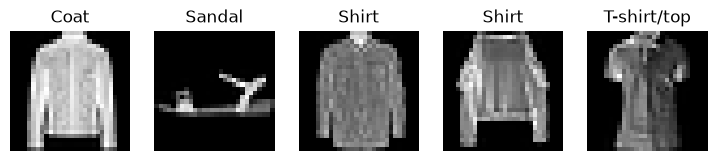

In [21]:
fig = plt.figure(figsize=(9, 9))
for i in range(0,5):
    random_idx = torch.randint(0,len(train_data),size = [1]).item()
    img,label = train_data[random_idx]
    fig.add_subplot(1, 5, i+1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);


In [23]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(train_data,
                              shuffle=True,
                              batch_size=BATCH_SIZE)

test_dataloader = DataLoader(test_data,
                             shuffle= False,
                             batch_size= BATCH_SIZE)

len(train_dataloader),len(test_dataloader)

(1875, 313)

In [57]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self,input_shape,output_shape,hidden_units = 10):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels= hidden_units,
                      kernel_size= 2,
                      stride= 1,
                      padding= 1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride = 1,
                      padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride =2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=2,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels = hidden_units,
                      padding = 1,
                      kernel_size=2,
                      stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride =2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*8*8,
                      out_features= output_shape)
        )

    def forward(self,x):
        return self.classifier(self.block2(self.block1(x)))
    

In [58]:
model_1 = FashionMNISTModelV1(input_shape= 1,
                             output_shape= len(class_names),
                             hidden_units=10)
model_1.to(device)

FashionMNISTModelV1(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=640, out_features=10, bias=True)
  )
)

In [59]:
images = torch.randn(size=(32,3,64,64))
test_image = images[0]
test_image.shape,images.shape

(torch.Size([3, 64, 64]), torch.Size([32, 3, 64, 64]))

In [60]:
from torchmetrics import Accuracy

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr=0.1)

acc_fn = Accuracy(task = "multiclass",num_classes= len(class_names)).to(device)

In [61]:
acc_fn.device,len(train_dataloader),len(train_data)

(device(type='cuda', index=0), 1875, 60000)

In [64]:
from tqdm.auto import tqdm

epochs = 5

for epoch in tqdm(range(epochs)):

    train_loss = 0 

    for batch,(X,y) in enumerate(train_dataloader):

        X = X.to(device)
        y = y.to(device)

        model_1.train()

        y_pred = model_1(X)

        loss = loss_fn(y_pred,y)

        train_loss +=loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if batch % 400 ==0 :
            print(f"Looked at {batch} samples")

    train_loss /= len(train_dataloader)

    test_loss = 0
    test_acc = 0

    model_1.eval()
    with torch.inference_mode():

        for X,y in test_dataloader:

            X = X.to(device)
            y = y.to(device)

        
            y_preds = model_1(X)

            loss = loss_fn(y_preds,y)
            Acc = acc_fn(y,y_preds.argmax(dim=1))

            test_loss +=loss
            test_acc += Acc

        test_loss /=len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"Epoch = {epoch} | Train Loss = {train_loss} | Test Loss = {test_loss} | Test Acc = {test_acc}")

  0%|          | 0/5 [00:00<?, ?it/s]

Looked at 0 samples
Looked at 400 samples
Looked at 800 samples
Looked at 1200 samples
Looked at 1600 samples


 20%|██        | 1/5 [00:07<00:29,  7.25s/it]

Epoch = 0 | Train Loss = 0.3258679509162903 | Test Loss = 0.33407074213027954 | Test Acc = 0.8790934085845947
Looked at 0 samples
Looked at 400 samples
Looked at 800 samples
Looked at 1200 samples
Looked at 1600 samples


 40%|████      | 2/5 [00:14<00:21,  7.32s/it]

...

Epoch = 2 | Train Loss = 0.29182904958724976 | Test Loss = 0.30864670872688293 | Test Acc = 0.8916733264923096
Looked at 0 samples
Looked at 400 samples
Looked at 800 samples
Looked at 1200 samples
Looked at 1600 samples


 80%|████████  | 4/5 [00:29<00:07,  7.31s/it]

Epoch = 3 | Train Loss = 0.28097090125083923 | Test Loss = 0.32016539573669434 | Test Acc = 0.8872803449630737
Looked at 0 samples
Looked at 400 samples
Looked at 800 samples
Looked at 1200 samples
Looked at 1600 samples


100%|██████████| 5/5 [00:36<00:00,  7.29s/it]

Epoch = 4 | Train Loss = 0.2734147906303406 | Test Loss = 0.2917464077472687 | Test Acc = 0.8965654969215393


In [70]:
import random

test_samples = []
test_labels = []

for sample,label in random.sample(list(test_data),k = 9):

    test_samples.append(sample)
    test_labels.append(label)

test_samples[0].shape,test_labels



(torch.Size([1, 28, 28]), [8, 8, 5, 2, 4, 4, 1, 9, 6])

In [84]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True,exist_ok = True)

MODEL_NAME = "FMNIST_CNN_Model"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj = model_1.state_dict(),f =MODEL_SAVE_PATH)